In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Screaping Dataset Hasil

In [ ]:
!pip -q install google-play-scraper pandas tqdm

import pandas as pd
from tqdm import tqdm
from google_play_scraper import reviews, Sort
import time
import re
import os

# =========================
# CONFIG
# =========================
DATA_DIR = "/content/drive/MyDrive/skripsi/dataset"
os.makedirs(DATA_DIR, exist_ok=True)

OUT_FILE = os.path.join(DATA_DIR, "datahasil.csv")

MIN_DATE = pd.Timestamp("2023-01-01")

# Jumlah review per aplikasi
APPS = [
    ("com.netflix.mediaclient", "Netflix", 20000),
    ("com.vuclip.viu", "Viu", 20000),
    ("com.tencent.qqlivei18n", "WeTV", 20000),
]

# =========================
# CLEAN TEXT BASIC
# =========================
def clean_basic(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

# =========================
# SCRAPER FUNCTION
# =========================
def scrape_playstore_filtered(app_id, app_name, target_n=5000, lang="id", country="id", sleep=0.25):

    all_reviews = []
    collected_ids = set()
    continuation_token = None
    stagnant_count = 0  # stop kalau 3 batch berturut-turut ga nambah data

    with tqdm(total=target_n, desc=f"Scraping {app_name}") as pbar:
        while len(all_reviews) < target_n:
            result, continuation_token = reviews(
                app_id,
                lang=lang,
                country=country,
                sort=Sort.NEWEST,
                count=200,
                continuation_token=continuation_token
            )

            if not result:
                break

            added_this_batch = 0
            valid_date_found = False

            for r in result:
                review_date = r.get("at")
                if review_date is None:
                    continue

                # ✅ filter minimal date: 2024+
                if pd.Timestamp(review_date) < MIN_DATE:
                    continue
                valid_date_found = True

                content = r.get("content")
                if not content:
                    continue

                content = clean_basic(content)

                # ✅ filter komentar pendek (min 3 kata)
                if len(content.split()) < 3:
                    continue

                review_id = r.get("reviewId")
                if review_id in collected_ids:
                    continue
                collected_ids.add(review_id)

                all_reviews.append({
                    "Nama Aplikasi": app_name,
                    "Nama Pengguna": r.get("userName"),9
                    "Komentar": content,
                    "Rating": r.get("score"),
                    "Tanggal Ulasan": review_date,
                })

                added_this_batch += 1
                if len(all_reviews) >= target_n:
                    break

            # update progress
            pbar.n = min(len(all_reviews), target_n)
            pbar.refresh()

            # stagnan handling
            if added_this_batch == 0:
                stagnant_count += 1
            else:
                stagnant_count = 0

            if stagnant_count >= 3:
                print(f"\n⚠️ Stagnant 3 batch berturut-turut. Stop scraping {app_name}.")
                break

            # stop kalau sudah tidak ada review >= MIN_DATE
            if not valid_date_found:
                print(f"\nℹ️ Tidak ada review >= {MIN_DATE.date()} lagi. Stop scraping {app_name}.")
                break

            if continuation_token is None:
                break

            time.sleep(sleep)

    return pd.DataFrame(all_reviews)

# =========================
# RUN SCRAPING
# =========================
dfs = []

for app_id, app_name, n in APPS:
    df_app = scrape_playstore_filtered(app_id, app_name, target_n=n)
    print(f"✅ {app_name} FINAL collected:", len(df_app))
    dfs.append(df_app)

df_master = pd.concat(dfs, ignore_index=True)

print("\n✅ MASTER DATASET TOTAL:", len(df_master))
print(df_master["Nama Aplikasi"].value_counts())
display(df_master.head())

# =========================
# SAVE TO DRIVE
# =========================
df_master.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")
print("\n✅ Saved to:", OUT_FILE)

# optional download
try:
    from google.colab import files
    files.download(OUT_FILE)
except:
    pass


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


Scraping Netflix:  75%|███████▍  | 14937/20000 [00:56<00:19, 263.65it/s]



ℹ️ Tidak ada review >= 2023-01-01 lagi. Stop scraping Netflix.
✅ Netflix FINAL collected: 14937


Scraping Viu:  74%|███████▍  | 14775/20000 [00:45<00:16, 324.01it/s]



ℹ️ Tidak ada review >= 2023-01-01 lagi. Stop scraping Viu.
✅ Viu FINAL collected: 14775


...


ℹ️ Tidak ada review >= 2023-01-01 lagi. Stop scraping WeTV.
✅ WeTV FINAL collected: 11349

✅ MASTER DATASET TOTAL: 41061
Nama Aplikasi
Netflix    14937
Viu        14775
WeTV       11349
Name: count, dtype: int64


,Nama Aplikasi,App ID,ID Ulasan,Nama Pengguna,Komentar,Rating,Jumlah Suka,Tanggal Ulasan
0,Netflix,com.netflix.mediaclient,1b73836b-2d15-466a-8528-03244f7c3e5d,Brii ii,"Netflix, when i clicked a NEW movie to watch, ...",2,0,2026-01-31 05:31:14
1,Netflix,com.netflix.mediaclient,958dcdf2-464c-41ac-9e00-590cad22ff65,Wirtz,aku hanya ingin bermain football manager 26 sa...,1,0,2026-01-31 05:30:15
2,Netflix,com.netflix.mediaclient,1e93814d-3bd5-45b6-b066-e1236bd7360b,Ekahartati Ekaeka,"aplikasi nya udah ke hapus ya, terus gak ada n...",1,0,2026-01-31 05:03:04
3,Netflix,com.netflix.mediaclient,51970a9d-9e35-4f0e-8aa3-199cb501c455,Lana Aja,"lambaaaaattttt, internet yang bisa lancar meng...",1,0,2026-01-31 04:41:04
4,Netflix,com.netflix.mediaclient,513085f5-70e2-44e4-990d-9fffb2d62479,Achmad Wadud,baru mau daftar AE suruh bayar hehe,1,0,2026-01-31 04:00:16



✅ Saved to: /content/drive/MyDrive/skripsi/dataset/datahasil.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cleaning Dataset Hasil


In [ ]:
# =========================================
# INSTALL & IMPORT
# =========================================
!pip install -q Sastrawi

import pandas as pd
import re
import os
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# =========================================
# PATH
# =========================================
DATA_DIR = "/content/drive/MyDrive/skripsi/dataset"
KAMUS_TYPO_FILE = os.path.join(DATA_DIR, "kamus/kamus_typo.csv")
KAMUS_GAUL_FILE = os.path.join(DATA_DIR, "kamus/kamus.csv")
DATA_FILE = os.path.join(DATA_DIR, "datahasil.csv")
OUT_FILE = os.path.join(DATA_DIR, "datahasil_clean.csv")

# =========================================
# LOAD DATA
# =========================================
df = pd.read_csv(DATA_FILE)
print("Jumlah data awal:", df.shape)

# =========================================
# LOAD & GABUNG KAMUS NORMALISASI
# =========================================
kamus_typo = pd.read_csv(KAMUS_TYPO_FILE)
kamus_gaul = pd.read_csv(KAMUS_GAUL_FILE)[["slang", "formal"]]

kamus_typo.columns = ["typo", "normal"]
kamus_gaul.columns = ["typo", "normal"]

kamus_all = pd.concat([kamus_typo, kamus_gaul], ignore_index=True)
kamus_all["typo"] = kamus_all["typo"].astype(str).str.lower().str.strip()
kamus_all["normal"] = kamus_all["normal"].astype(str).str.lower().str.strip()
kamus_all = kamus_all.drop_duplicates(subset="typo", keep="first")

kamus_normalisasi = dict(zip(kamus_all["typo"], kamus_all["normal"]))

kamus_frasa = {k: v for k, v in kamus_normalisasi.items() if " " in k}
kamus_kata  = {k: v for k, v in kamus_normalisasi.items() if " " not in k}

print("Total entri kamus normalisasi:", len(kamus_normalisasi))

# =========================================
# STOPWORD, NEGASI, KONJUNGSI
# =========================================
stopwords = set("""
yang dan di ke dari untuk pada dengan adalah itu ini karena sebagai juga
agar supaya atau sehingga dalam sudah sangat lebih kurang saja hanya masih
bisa dapat harus akan jadi pun lah kah nya si sang para
""".split())

# Kata negasi (dipertahankan & digabung)
negasi = {
    "tidak","bukan","belum","jangan","tak",
    "tdk","bkn","ga","gak","gk","nggak","ngga","enggak","kagak"
}

# Konjungsi pemisah opini (JANGAN DIHAPUS)
konjungsi_pemisah = {
    "tapi","namun","tetapi","walaupun","meskipun","padahal","sedangkan","cuma"
}

# Stopword dikurangi negasi & konjungsi penting
stopwords = stopwords - negasi - konjungsi_pemisah

# =========================================
# INIT STEMMER
# =========================================
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# =========================================
# CLEANING DASAR
# =========================================
def clean_basic(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = re.sub(r"\b(wk+w*k+|ha+ha+|he+he+|xixixi+|wkwk+)\b", " ", text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# =========================================
# NORMALISASI TYPO & SLANG
# =========================================
def normalize_text(text):
    for typo, normal in kamus_frasa.items():
        text = re.sub(rf"\b{re.escape(typo)}\b", normal, text)
    words = text.split()
    words = [kamus_kata.get(w, w) for w in words]
    return " ".join(words)

# =========================================
# HANDLE NEGASI (tidak bagus → tidak_bagus)
# =========================================
def handle_negation(text):
    tokens = text.split()
    hasil = []
    i = 0
    while i < len(tokens):
        if tokens[i] in negasi and i+1 < len(tokens):
            hasil.append(tokens[i] + "_" + tokens[i+1])
            i += 2
        else:
            hasil.append(tokens[i])
            i += 1
    return " ".join(hasil)

# =========================================
# STOPWORD REMOVAL (AMAN)
# =========================================
def remove_stopwords(text):
    hasil = []
    for w in text.split():
        if "_" in w:  # token negasi dijaga
            hasil.append(w)
        elif w in konjungsi_pemisah:  # konjungsi dipertahankan
            hasil.append(w)
        elif w not in stopwords:
            hasil.append(w)
    return " ".join(hasil)

# =========================================
# STEMMING
# =========================================
def safe_stem(text):
    hasil = []
    for w in text.split():
        if "_" in w:
            hasil.append(w)
        else:
            hasil.append(stemmer.stem(w))
    return " ".join(hasil)

# =========================================
# FILTER ULASAN TIDAK BERMAKNA
# =========================================
def is_meaningful(text):
    tokens = text.split()
    if len(tokens) <= 1:
        return False
    if len(set(tokens)) == 1 and tokens[0] not in negasi:
        return False
    return True

# =========================================
# PIPELINE
# =========================================
df["clean_text"] = df["Komentar"].apply(clean_basic)
df["clean_text"] = df["clean_text"].apply(normalize_text)
df["clean_text"] = df["clean_text"].apply(handle_negation)
df["clean_text"] = df["clean_text"].apply(remove_stopwords)

print("Sebelum filter:", df.shape)
df = df[df["clean_text"].apply(is_meaningful)].copy()
print("Setelah filter:", df.shape)

df["clean_text_stem"] = df["clean_text"].apply(safe_stem)

df = df[df["clean_text_stem"].str.strip() != ""]
df = df[df["clean_text_stem"].str.split().str.len() > 1]

# =========================================
# SAVE
# =========================================
df.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")
print("Dataset bersih disimpan di:", OUT_FILE)
print("Shape akhir:", df.shape)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.3 MB/s eta 0:00:00
Jumlah data awal: (41061, 8)
Total entri kamus normalisasi: 4413
Sebelum filter: (41061, 9)
Setelah filter: (40926, 9)
Dataset bersih disimpan di: /content/drive/MyDrive/skripsi/dataset/datahasil_clean.csv
Shape akhir: (40926, 10)


Screaping Dataset Latih

In [ ]:
!pip -q install google-play-scraper pandas tqdm

import pandas as pd
from tqdm import tqdm
from google_play_scraper import reviews, Sort
import time
import re
import os

# =========================
# CONFIG
# =========================
DATA_DIR = "/content/drive/MyDrive/skripsi/dataset"
os.makedirs(DATA_DIR, exist_ok=True)

OUT_FILE = os.path.join(DATA_DIR, "datasetmentah.csv")

MIN_DATE = pd.Timestamp("2023-01-01")

# Jumlah review per aplikasi
APPS = [
    ("com.netflix.mediaclient", "Netflix", 10000),
    ("com.vuclip.viu", "Viu", 10000),
    ("com.tencent.qqlivei18n", "WeTV", 10000),
]

# =========================
# CLEAN TEXT BASIC
# =========================
def clean_basic(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

# =========================
# SCRAPER FUNCTION
# =========================
def scrape_playstore_filtered(app_id, app_name, target_n=5000, lang="id", country="id", sleep=0.25):

    all_reviews = []
    collected_ids = set()
    continuation_token = None
    stagnant_count = 0  # stop kalau 3 batch berturut-turut ga nambah data

    with tqdm(total=target_n, desc=f"Scraping {app_name}") as pbar:
        while len(all_reviews) < target_n:
            result, continuation_token = reviews(
                app_id,
                lang=lang,
                country=country,
                sort=Sort.NEWEST,
                count=200,
                continuation_token=continuation_token
            )

            if not result:
                break

            added_this_batch = 0
            valid_date_found = False

            for r in result:
                review_date = r.get("at")
                if review_date is None:
                    continue

                # ✅ filter minimal date: 2024+
                if pd.Timestamp(review_date) < MIN_DATE:
                    continue
                valid_date_found = True

                content = r.get("content")
                if not content:
                    continue

                content = clean_basic(content)

                # ✅ filter komentar pendek (min 3 kata)
                if len(content.split()) < 3:
                    continue

                review_id = r.get("reviewId")
                if review_id in collected_ids:
                    continue
                collected_ids.add(review_id)

                all_reviews.append({
                    "Nama Aplikasi": app_name,
                    "Nama Pengguna": r.get("userName"),9
                    "Komentar": content,
                    "Rating": r.get("score"),
                    "Tanggal Ulasan": review_date,
                })
                added_this_batch += 1
                if len(all_reviews) >= target_n:
                    break

            # update progress
            pbar.n = min(len(all_reviews), target_n)
            pbar.refresh()

            # stagnan handling
            if added_this_batch == 0:
                stagnant_count += 1
            else:
                stagnant_count = 0

            if stagnant_count >= 3:
                print(f"\n⚠️ Stagnant 3 batch berturut-turut. Stop scraping {app_name}.")
                break

            # stop kalau sudah tidak ada review >= MIN_DATE
            if not valid_date_found:
                print(f"\nℹ️ Tidak ada review >= {MIN_DATE.date()} lagi. Stop scraping {app_name}.")
                break

            if continuation_token is None:
                break

            time.sleep(sleep)

    return pd.DataFrame(all_reviews)

# =========================
# RUN SCRAPING
# =========================
dfs = []

for app_id, app_name, n in APPS:
    df_app = scrape_playstore_filtered(app_id, app_name, target_n=n)
    print(f"✅ {app_name} FINAL collected:", len(df_app))
    dfs.append(df_app)

df_master = pd.concat(dfs, ignore_index=True)

print("\n✅ MASTER DATASET TOTAL:", len(df_master))
print(df_master["Nama Aplikasi"].value_counts())
display(df_master.head())

# =========================
# SAVE TO DRIVE
# =========================
df_master.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")
print("\n✅ Saved to:", OUT_FILE)

# optional download
try:
    from google.colab import files
    files.download(OUT_FILE)
except:
    pass


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00


Scraping Netflix:   3%|▎         | 311/10000 [00:01<00:52, 185.96it/s]


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import os

DATA_DIR = "/content/drive/MyDrive/skripsi/dataset"
IN_FILE  = os.path.join(DATA_DIR, "datasetmentah.csv")  # pastikan nama file benar

df = pd.read_csv(IN_FILE)

print("✅ Dataset mentah loaded:", df.shape)
print(df.head())


✅ Dataset mentah loaded: (30000, 8)
  Nama Aplikasi                   App ID  \
0       Netflix  com.netflix.mediaclient   
1       Netflix  com.netflix.mediaclient   
2       Netflix  com.netflix.mediaclient   
3       Netflix  com.netflix.mediaclient   
4       Netflix  com.netflix.mediaclient   

                              ID Ulasan        Nama Pengguna  \
0  a8c4519f-5e17-42cf-8d2f-7f7b4dc35e96       Reza purnama.t   
1  63f9a32f-3d76-4ed4-beee-502fe3b41edc         ira sofiyani   
2  a68a8a5a-9a2c-45e6-9542-15e158174301  Nurus syamsi Syamsi   
3  419d9855-4dd9-4967-896c-9c38f11f9edb        Planet Review   
4  180b135d-39b4-4afc-9615-65547bb5eee9         Qaila Apriza   

                                            Komentar  Rating  Jumlah Suka  \
0                                gabisa nonton anjoy       1            0   
1           loading doang gak kebuka filmnya...hadew       1            0   
2  please tambah urki series dong min judulnya ar...       5            0   
3     

Cleaning Dataset Latih

In [ ]:
# =========================================
# INSTALL & IMPORT
# =========================================
!pip install -q Sastrawi

import pandas as pd
import re
import os
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# =========================================
# PATH
# =========================================
DATA_DIR = "/content/drive/MyDrive/skripsi/dataset"
KAMUS_TYPO_FILE = os.path.join(DATA_DIR, "kamus/kamus_typo.csv")
KAMUS_GAUL_FILE = os.path.join(DATA_DIR, "kamus/kamus.csv")
DATA_FILE = os.path.join(DATA_DIR, "datasetmentah.csv")
OUT_FILE = os.path.join(DATA_DIR, "dataset_clean.csv")

# =========================================
# LOAD DATA
# =========================================
df = pd.read_csv(DATA_FILE)
print("Jumlah data awal:", df.shape)

# =========================================
# LOAD & GABUNG KAMUS NORMALISASI
# =========================================
kamus_typo = pd.read_csv(KAMUS_TYPO_FILE)
kamus_gaul = pd.read_csv(KAMUS_GAUL_FILE)[["slang", "formal"]]

kamus_typo.columns = ["typo", "normal"]
kamus_gaul.columns = ["typo", "normal"]

kamus_all = pd.concat([kamus_typo, kamus_gaul], ignore_index=True)
kamus_all["typo"] = kamus_all["typo"].astype(str).str.lower().str.strip()
kamus_all["normal"] = kamus_all["normal"].astype(str).str.lower().str.strip()
kamus_all = kamus_all.drop_duplicates(subset="typo", keep="first")

kamus_normalisasi = dict(zip(kamus_all["typo"], kamus_all["normal"]))

kamus_frasa = {k: v for k, v in kamus_normalisasi.items() if " " in k}
kamus_kata  = {k: v for k, v in kamus_normalisasi.items() if " " not in k}

print("Total entri kamus normalisasi:", len(kamus_normalisasi))

# =========================================
# STOPWORD, NEGASI, KONJUNGSI
# =========================================
stopwords = set("""
yang dan di ke dari untuk pada dengan adalah itu ini karena sebagai juga
agar supaya atau sehingga dalam sudah sangat lebih kurang saja hanya masih
bisa dapat harus akan jadi pun lah kah nya si sang para
""".split())

# Kata negasi (dipertahankan & digabung)
negasi = {
    "tidak","bukan","belum","jangan","tak",
    "tdk","bkn","ga","gak","gk","nggak","ngga","enggak","kagak"
}

# Konjungsi pemisah opini (JANGAN DIHAPUS)
konjungsi_pemisah = {
    "tapi","namun","tetapi","walaupun","meskipun","padahal","sedangkan"
}

# Stopword dikurangi negasi & konjungsi penting
stopwords = stopwords - negasi - konjungsi_pemisah

# =========================================
# INIT STEMMER
# =========================================
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# =========================================
# CLEANING DASAR
# =========================================
def clean_basic(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = re.sub(r"\b(wk+w*k+|ha+ha+|he+he+|xixixi+|wkwk+)\b", " ", text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# =========================================
# NORMALISASI TYPO & SLANG
# =========================================
def normalize_text(text):
    for typo, normal in kamus_frasa.items():
        text = re.sub(rf"\b{re.escape(typo)}\b", normal, text)
    words = text.split()
    words = [kamus_kata.get(w, w) for w in words]
    return " ".join(words)

# =========================================
# HANDLE NEGASI (tidak bagus → tidak_bagus)
# =========================================
def handle_negation(text):
    tokens = text.split()
    hasil = []
    i = 0
    while i < len(tokens):
        if tokens[i] in negasi and i+1 < len(tokens):
            hasil.append(tokens[i] + "_" + tokens[i+1])
            i += 2
        else:
            hasil.append(tokens[i])
            i += 1
    return " ".join(hasil)

# =========================================
# STOPWORD REMOVAL (AMAN)
# =========================================
def remove_stopwords(text):
    hasil = []
    for w in text.split():
        if "_" in w:  # token negasi dijaga
            hasil.append(w)
        elif w in konjungsi_pemisah:  # konjungsi dipertahankan
            hasil.append(w)
        elif w not in stopwords:
            hasil.append(w)
    return " ".join(hasil)

# =========================================
# STEMMING
# =========================================
def safe_stem(text):
    hasil = []
    for w in text.split():
        if "_" in w:
            hasil.append(w)
        else:
            hasil.append(stemmer.stem(w))
    return " ".join(hasil)

# =========================================
# FILTER ULASAN TIDAK BERMAKNA
# =========================================
def is_meaningful(text):
    tokens = text.split()
    if len(tokens) <= 1:
        return False
    if len(set(tokens)) == 1 and tokens[0] not in negasi:
        return False
    return True

# =========================================
# PIPELINE
# =========================================
df["clean_text"] = df["Komentar"].apply(clean_basic)
df["clean_text"] = df["clean_text"].apply(normalize_text)
df["clean_text"] = df["clean_text"].apply(handle_negation)
df["clean_text"] = df["clean_text"].apply(remove_stopwords)

print("Sebelum filter:", df.shape)
df = df[df["clean_text"].apply(is_meaningful)].copy()
print("Setelah filter:", df.shape)

df["clean_text_stem"] = df["clean_text"].apply(safe_stem)

df = df[df["clean_text_stem"].str.strip() != ""]
df = df[df["clean_text_stem"].str.split().str.len() > 1]

# =========================================
# SAVE
# =========================================
df.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")
print("Dataset bersih disimpan di:", OUT_FILE)
print("Shape akhir:", df.shape)


Jumlah data awal: (30000, 8)
Total entri kamus normalisasi: 4413
Sebelum filter: (30000, 9)
Setelah filter: (29904, 9)
Dataset bersih disimpan di: /content/drive/MyDrive/skripsi/dataset/dataset_clean.csv
Shape akhir: (29904, 10)


PELABELAN SENTIMEN

In [ ]:
import pandas as pd
import os

# =========================
# PATH
# =========================
DATA_DIR = "/content/drive/MyDrive/skripsi/dataset"
IN_FILE  = os.path.join(DATA_DIR, "dataset_clean.csv")
OUT_FILE = os.path.join(DATA_DIR, "dataset_sentimen.csv")

print("Input file  :", IN_FILE)
print("Output file :", OUT_FILE)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(IN_FILE)
print("\nJumlah data awal:", df.shape)

# =========================
# VALIDASI RATING
# =========================
df = df.dropna(subset=["Rating"])
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df = df.dropna(subset=["Rating"])
print("Jumlah data setelah membersihkan rating tidak valid:", df.shape)

# =========================
# KONVERSI RATING MENJADI LABEL SENTIMEN
# =========================
def rating_to_sentimen(r):
    if r <= 2:
        return "negatif"
    elif r >= 4:
        return "positif"
    else:
        return "netral"

df["Sentimen"] = df["Rating"].apply(rating_to_sentimen)

print("\nDistribusi sentimen sebelum menghapus netral:")
print(df["Sentimen"].value_counts())

# =========================
# HAPUS KELAS NETRAL (BINARY CLASSIFICATION)
# =========================
df = df[df["Sentimen"] != "netral"].copy()

print("\nDistribusi sentimen setelah menghapus netral:")
print(df["Sentimen"].value_counts())
print("Jumlah data akhir untuk klasifikasi biner:", df.shape)

# =========================
# PASTIKAN TEKS BERSIH
# =========================
df = df[df["clean_text_stem"].str.strip() != ""]
df = df[df["clean_text_stem"].str.split().str.len() > 1]

# =========================
# STANDARISASI NAMA APLIKASI
# =========================
df["Nama Aplikasi"] = df["Nama Aplikasi"].astype(str).str.lower().str.strip()

# =========================
# PILIH KOLOM YANG DIGUNAKAN
# =========================
kolom_penting = [
    "Nama Aplikasi",
    "Komentar",
    "clean_text",
    "clean_text_stem",
    "Rating",
    "Sentimen"
]

kolom_final = [k for k in kolom_penting if k in df.columns]
df_final = df[kolom_final].copy()

print("\nKolom yang digunakan dalam dataset akhir:")
print(df_final.columns.tolist())

# =========================
# CEK NILAI KOSONG
# =========================
print("\nJumlah missing value per kolom:")
print(df_final.isnull().sum())

print("\nRasio distribusi kelas:")
print(df_final["Sentimen"].value_counts(normalize=True).round(3))

# =========================
# SIMPAN DATASET
# =========================
df_final.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

print("\nDataset sentimen siap untuk proses modeling disimpan di:")
print(OUT_FILE)

print("\nContoh beberapa baris data:")
display(df_final.sample(5))


Input file  : /content/drive/MyDrive/skripsi/dataset/dataset_clean.csv
Output file : /content/drive/MyDrive/skripsi/dataset/dataset_sentimen.csv

Jumlah data awal: (29904, 10)
Jumlah data setelah membersihkan rating tidak valid: (29904, 10)

Distribusi sentimen sebelum menghapus netral:
Sentimen
negatif    18296
positif     8517
netral      3091
Name: count, dtype: int64

Distribusi sentimen setelah menghapus netral:
Sentimen
negatif    18296
positif     8517
Name: count, dtype: int64
Jumlah data akhir untuk klasifikasi biner: (26813, 11)

Kolom yang digunakan dalam dataset akhir:
['Nama Aplikasi', 'Komentar', 'clean_text', 'clean_text_stem', 'Rating', 'Sentimen']

Jumlah missing value per kolom:
Nama Aplikasi      0
Komentar           0
clean_text         0
clean_text_stem    0
Rating             0
Sentimen           0
dtype: int64

Rasio distribusi kelas:
Sentimen
negatif    0.682
positif    0.318
Name: proportion, dtype: float64

Dataset sentimen siap untuk proses modeling disimpan 

,Nama Aplikasi,Komentar,clean_text,clean_text_stem,Rating,Sentimen
17303,viu,Barusan coba download apk ini tp g bs dibuka k...,barusan coba download aplikasi enggak_bisa dib...,barusan coba download aplikasi enggak_bisa buk...,2,negatif
25967,wetv,Komen ini tidak asli.Yang asli ada badaknya😆,komen tidak_asli asli ada badaknya,komen tidak_asli asli ada badak,4,positif
14498,viu,Aplikasi sangat bagus,aplikasi bagus,aplikasi bagus,5,positif
3906,netflix,Film sma drama korea ny di perbanyak lagi trtm...,film sama drama korea perbanyak lagi trtma dra...,film sama drama korea banyak lagi trtma drama ...,5,positif
19351,viu,Aplikasinya sangat bagus dan keren karena apli...,aplikasinya bagus keren aplikasinya film korea...,aplikasi bagus keren aplikasi film korea asia ...,5,positif


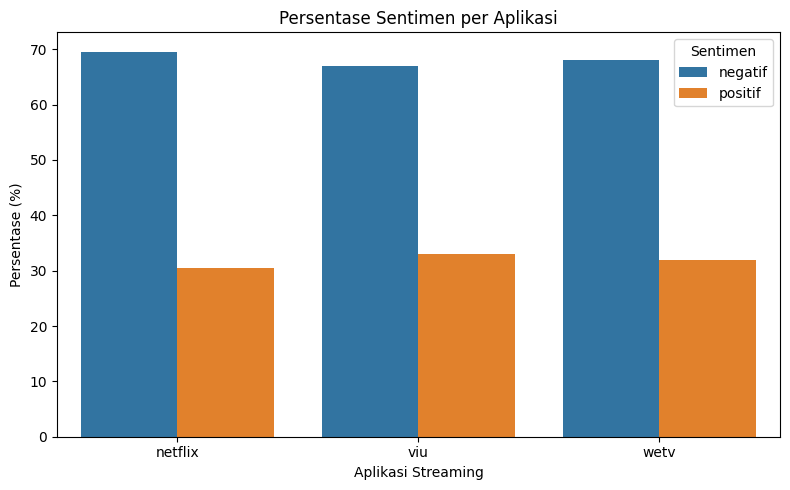

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_percent,
    x="Nama Aplikasi",
    y="Persentase",
    hue="Sentimen"
)

plt.title("Persentase Sentimen per Aplikasi")
plt.xlabel("Aplikasi Streaming")
plt.ylabel("Persentase (%)")
plt.legend(title="Sentimen")
plt.tight_layout()
plt.show()


PELABELAN ASPEK

In [ ]:
# =========================================================
# PELABELAN ASPEK OTOMATIS BERBASIS KALIMAT (FINAL)
# =========================================================

import pandas as pd
import re
import os
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# =========================
# PATH
# =========================
DATA_DIR = "/content/drive/MyDrive/skripsi/dataset"
DATA_FILE = os.path.join(DATA_DIR, "dataset_clean.csv")
KAMUS_ASPEK_FILE = os.path.join(DATA_DIR, "kamus/kamus_aspek.csv")
OUT_DATASET = os.path.join(DATA_DIR, "dataset_aspek.csv")

# =========================
# LOAD DATASET CLEAN
# =========================
df = pd.read_csv(DATA_FILE)
df = df.dropna(subset=["clean_text_stem"])
df["clean_text_stem"] = df["clean_text_stem"].astype(str).str.lower()

print("Jumlah data ulasan:", len(df))

# =========================
# STEMMER (UNTUK STEM KAMUS)
# =========================
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# =========================
# LOAD & STEM KAMUS ASPEK
# =========================
df_kamus = pd.read_csv(KAMUS_ASPEK_FILE)
df_kamus["Keyword"] = df_kamus["Keyword"].astype(str).str.lower().str.strip()
df_kamus["Keyword_stem"] = df_kamus["Keyword"].apply(stemmer.stem)

kamus_aspek = {
    aspek: sorted(set(group["Keyword_stem"]))
    for aspek, group in df_kamus.groupby("Aspek")
}

print("Daftar aspek:", list(kamus_aspek.keys()))

# =========================
# SPLIT KALIMAT MENJADI OPINI
# =========================
def split_kalimat(teks):
    teks = str(teks).lower().strip()
    kalimat_awal = re.split(r'[.!?]+', teks)

    hasil = []
    for kal in kalimat_awal:
        kal = kal.strip()
        if not kal:
            continue

        sub = re.split(r'\b(tapi|namun|tetapi|walaupun|meskipun|padahal)\b', kal)
        for b in sub:
            b = b.strip()
            if b and b not in ["tapi","namun","tetapi","walaupun","meskipun","padahal"]:
                hasil.append(b)

    return hasil

df["Kalimat_List"] = df["clean_text_stem"].apply(split_kalimat)
df_kalimat = df.explode("Kalimat_List").rename(columns={"Kalimat_List": "kalimat"})
df_kalimat["kalimat"] = df_kalimat["kalimat"].str.strip()

# Buang kalimat terlalu pendek
df_kalimat = df_kalimat[df_kalimat["kalimat"].str.split().str.len() > 1]

print("Jumlah kalimat opini:", len(df_kalimat))

# =========================
# HITUNG SKOR ASPEK
# =========================
def hitung_aspek(text):
    text = re.sub(r"[^a-z0-9_\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    skor = {}
    for aspek, keywords in kamus_aspek.items():
        total = 0
        for kw in keywords:
            if re.search(r'\b' + re.escape(kw) + r'\b', text):
                total += len(kw.split())  # frasa dapat bobot lebih
        if total > 0:
            skor[aspek] = total

    return skor

# =========================
# PRIORITAS JIKA SKOR SAMA
# =========================
prioritas_aspek = [
    "Akun & Akses",
    "Kualitas Streaming",
    "Harga & Pembayaran",
    "Konten",
    "Aplikasi & Fitur"
]

def tentukan_aspek(text):
    skor = hitung_aspek(text)

    if not skor:
        return "Umum"

    max_skor = max(skor.values())
    kandidat = [a for a,v in skor.items() if v == max_skor]

    if len(kandidat) == 1:
        return kandidat[0]

    for p in prioritas_aspek:
        if p in kandidat:
            return p

    return kandidat[0]

df_kalimat["Aspek"] = df_kalimat["kalimat"].apply(tentukan_aspek)

# =========================
# DATASET FINAL
# =========================
df_final = df_kalimat[[
    "Nama Aplikasi",
    "Komentar",          # komentar asli
    "clean_text_stem",   # hasil preprocessing utuh
    "kalimat",           # pecahan opini
    "Aspek"
]]

df_final.to_csv(OUT_DATASET, index=False, encoding="utf-8-sig")

print("\nDataset aspek berhasil dibuat:", OUT_DATASET)
print("\nDistribusi aspek:")
print(df_final["Aspek"].value_counts())

print("\nContoh data:")
display(df_final.sample(10))


Jumlah data ulasan: 29904
Daftar aspek: ['Akun & Akses', 'Aplikasi & Fitur', 'Harga & Pembayaran', 'Konten', 'Kualitas Streaming']
Jumlah kalimat opini: 33846

Dataset aspek berhasil dibuat: /content/drive/MyDrive/skripsi/dataset/dataset_aspek.csv

Distribusi aspek:
Aspek
Aplikasi & Fitur      8161
Harga & Pembayaran    7186
Konten                7110
Umum                  4952
Akun & Akses          4810
Kualitas Streaming    1627
Name: count, dtype: int64

Contoh data:


,Nama Aplikasi,Komentar,clean_text_stem,kalimat,Aspek
1493,Netflix,"Customer service didn't help me at all, even s...",customer service didn t help me at all even st...,customer service didn t help me at all even st...,Akun & Akses
20116,WeTV,nyesal dwon load buang buat paket data ku aja,nyesal dwon load buang buat paket data ku,nyesal dwon load buang buat paket data ku,Harga & Pembayaran
425,Netflix,"nekflix di tv smart saya versi 8.xxx, dan skrg...",nekflix tv smart saya versi 8 xx sekarang vers...,nekflix tv smart saya versi 8 xx sekarang vers...,Aplikasi & Fitur
174,Netflix,sudah lakukan pembayaran tapi tetep tidak bisa...,laku bayar tetap tidak_bisa masuk akun coba ul...,laku bayar tetap tidak_bisa masuk akun coba ul...,Akun & Akses
17490,Viu,Rasanya semalam nonton baik2 aja....siang ini ...,rasa malam tonton baik siang mau tonton minta ...,rasa malam tonton baik siang mau tonton minta ...,Aplikasi & Fitur
27391,WeTV,Iklan nya buset sampe 4 kali.,iklan buset sampai 4 kali,iklan buset sampai 4 kali,Aplikasi & Fitur
29006,WeTV,Padahal VIP tapi CC nya munculnya besoknya sam...,padahal vip cc muncul besok sama kayak free as...,vip cc muncul besok sama kayak free asa percum...,Harga & Pembayaran
2241,Netflix,gk bagus sekali anj,tidak_bagus sekali anjing,tidak_bagus sekali anjing,Umum
12160,Viu,banyak bgt iklan,banyak banget iklan,banyak banget iklan,Aplikasi & Fitur
2738,Netflix,Aplikasi buruk mau daftar akun ajah dipersulit...,aplikasi buruk mau daftar akun sulit aplikasi ...,aplikasi buruk mau daftar akun sulit aplikasi ...,Akun & Akses


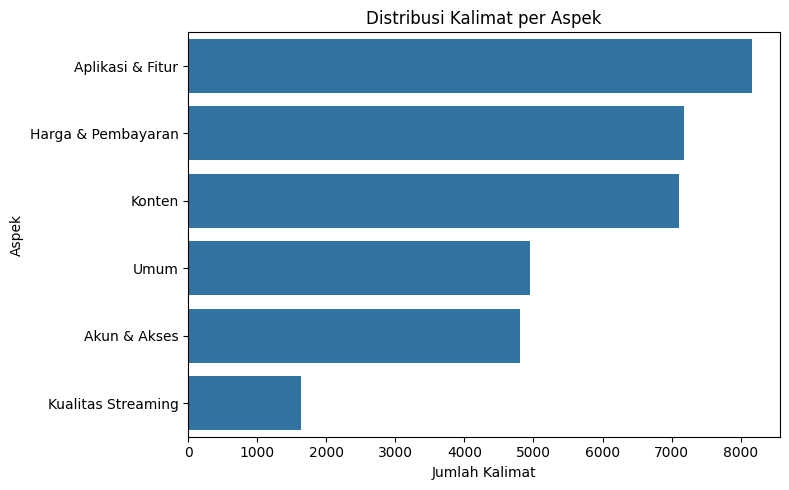

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df_kalimat, y="Aspek", order=df_kalimat["Aspek"].value_counts().index)
plt.title("Distribusi Kalimat per Aspek")
plt.xlabel("Jumlah Kalimat")
plt.ylabel("Aspek")
plt.tight_layout()
plt.show()
